In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    TimeSeriesSplit, cross_val_score, GridSearchCV
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:

root = Path.cwd()
if not(root / "Data/HousePrice_Dataset.csv").exists():
    root=Path("..")

houseprice_datasetpath = root / "Data/HousePrice_Dataset.csv"

df = pd.read_csv(houseprice_datasetpath)

print("\nShape:",df.shape)
display(df.head())
print()
display(df.info())


Shape: (3800, 12)


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


None

# Part B: Dataset Understanding & Preparation

In [3]:
# features and target variable

X=df.drop(columns=["property_id","sale_date","house_price_inr"])
y=df["house_price_inr"]


print("Target: house_price_inr")
print("\nFeatures:\n",list(X.columns))
print("\nMissing valuse:")
display(df.isna().sum().to_frame("Missing_Count"))

Target: house_price_inr

Features:
 ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']

Missing valuse:


,Missing_Count
property_id,0
sale_date,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
property_age,0
distance_city_km,0
near_school,0
near_metro,0


In [4]:
# train–test split.

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

fretures =  X_train.select_dtypes(
    include=["int64", "float64"]
).columns

In [5]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline,fretures)
])

# Regularized Linear Models

In [6]:
alpha_grid = {"model__alpha": np.logspace(-3,4,12)}

ridge_pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("model",Ridge())
])

lasso_pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("model",Lasso())
])

ridge_search = GridSearchCV(
    ridge_pipe,alpha_grid,cv=5,scoring="neg_root_mean_squared_error",n_jobs=1
)

lasso_search = GridSearchCV(
    lasso_pipe,alpha_grid,cv=5,scoring="neg_root_mean_squared_error",n_jobs=1
)

ridge_search.fit(X_train,y_train)
lasso_search.fit(X_train,y_train)


print("Bast Ridge:",ridge_search.best_params_)
print("Bast Lasso:",lasso_search.best_params_)

Bast Ridge: {'model__alpha': 0.3511191734215131}
Bast Lasso: {'model__alpha': 10000.0}


In [7]:
def regression_metrics(model_name, estimator, X_tr, y_tr, X_te, y_te):
    pred_train = estimator.predict(X_tr)
    pred_test = estimator.predict(X_te)
    return {
        "model": model_name,
        "train_mse": mean_squared_error(y_tr, pred_train),
        "test_mse": mean_squared_error(y_te, pred_test),
        "train_mae": mean_absolute_error(y_tr, pred_train),
        "test_mae": mean_absolute_error(y_te, pred_test),
        "train_rmse": mean_squared_error(y_tr, pred_train, squared=False),
        "test_rmse": mean_squared_error(y_te, pred_test, squared=False),
        "train_r2": r2_score(y_tr, pred_train),
        "test_r2": r2_score(y_te, pred_test),
    }

linear_results = pd.DataFrame([
    regression_metrics("Ridge", ridge_search.best_estimator_, X_train, y_train, X_test, y_test),
    regression_metrics("Lasso", lasso_search.best_estimator_, X_train, y_train, X_test, y_test),
])
display(linear_results)


C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root 

,model,train_mse,test_mse,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Ridge,6.253031e+12,6.544492e+12,1.911863e+06,1.959315e+06,2.500606e+06,2.558220e+06,0.916186,0.918737
1,Lasso,6.253664e+12,6.555773e+12,1.910686e+06,1.960123e+06,2.500733e+06,2.560424e+06,0.916177,0.918597


In [8]:
def show_coefficients(fitted_pipeline, title):
    model = fitted_pipeline.named_steps["model"]
    prep = fitted_pipeline.named_steps["preprocessor"]
    try:
        names = prep.get_feature_names_out()
        coeffs = pd.Series(model.coef_, index=names).sort_values(key=np.abs, ascending=False)
        print(title)
        display(coeffs.head(15).to_frame("coefficient"))
    except Exception as exc:
        print("Coefficient inspection unavailable:", exc)

show_coefficients(ridge_search.best_estimator_, "Ridge coefficients")
show_coefficients(lasso_search.best_estimator_, "Lasso coefficients")

Ridge coefficients


,coefficient
numeric__area_sqft,6.942312e+06
numeric__location_score,3.678230e+06
numeric__property_age,-6.514198e+05
numeric__bedrooms,2.933700e+05
numeric__bathrooms,2.853939e+05
numeric__crime_rate_index,-1.354268e+05
numeric__near_metro,5.826461e+04
numeric__distance_city_km,-2.928139e+04
numeric__near_school,1.692969e+04


Lasso coefficients


,coefficient
numeric__area_sqft,6.938214e+06
numeric__location_score,3.673262e+06
numeric__property_age,-6.422511e+05
numeric__bedrooms,2.907946e+05
numeric__bathrooms,2.801473e+05
numeric__crime_rate_index,-1.260846e+05
numeric__near_metro,4.825058e+04
numeric__distance_city_km,-2.254400e+04
numeric__near_school,6.554514e+03


# Cross-Validation Strategies

In [10]:
RANDOM_STATE=42

In [12]:
# 8. Compare CV strategies using Ridge
X_all = X.reset_index(drop=True)
y_all = y.reset_index(drop=True)

ridge_model = ridge_search.best_estimator_

cv_results = []

# K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = -cross_val_score(ridge_model, X_all, y_all, cv=kf,
                          scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_results.append({"strategy": "K-Fold", "mean_rmse": scores.mean(), "std_rmse": scores.std()})

# Stratified K-Fold using target bins
target_bins = pd.qcut(y_all, q=5, labels=False, duplicates="drop")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = -cross_val_score(ridge_model, X_all, y_all, cv=skf.split(X_all, target_bins),
                          scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_results.append({"strategy": "Stratified K-Fold (target bins)", "mean_rmse": scores.mean(), "std_rmse": scores.std()})

# LOOCV on a reduced sample for practical runtime
small_n = min(150, len(X_all))
X_small, y_small = X_all.iloc[:small_n], y_all.iloc[:small_n]
loo = LeaveOneOut()
loo_scores = -cross_val_score(ridge_model, X_small, y_small, cv=loo,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_results.append({"strategy": "LOOCV (first 150 rows max)", "mean_rmse": loo_scores.mean(), "std_rmse": loo_scores.std()})

cv_comparison = pd.DataFrame(cv_results)
display(cv_comparison)


,strategy,mean_rmse,std_rmse
0,K-Fold,2.516719e+06,9.302539e+04
1,Stratified K-Fold (target bins),2.514799e+06,6.119556e+04
2,LOOCV (first 150 rows max),2.269652e+06,1.831096e+06


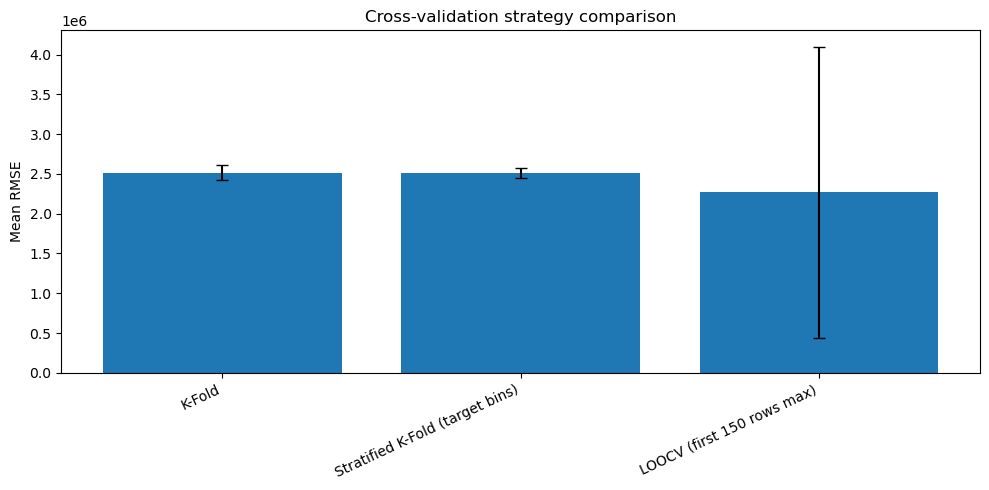

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(cv_comparison["strategy"], cv_comparison["mean_rmse"], yerr=cv_comparison["std_rmse"], capsize=4)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean RMSE")
plt.title("Cross-validation strategy comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_comparison.png", dpi=160)
plt.show()

# Tree-Based Regression Models

In [18]:
tree_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])
tree_grid = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_leaf": [1, 3, 8, 15]
}
tree_search = GridSearchCV(tree_pipe, tree_grid, cv=5,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
tree_search.fit(X_train, y_train)

forest_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])
forest_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8, 15],
    "model__min_samples_leaf": [1, 3, 8]
}
forest_search = GridSearchCV(forest_pipe, forest_grid, cv=5,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
forest_search.fit(X_train, y_train)

print("Best tree:", tree_search.best_params_)
print("Best forest:", forest_search.best_params_)

Best tree: {'model__max_depth': 12, 'model__min_samples_leaf': 15}
Best forest: {'model__max_depth': None, 'model__min_samples_leaf': 8, 'model__n_estimators': 200}


In [19]:
tree_results = pd.DataFrame([
    regression_metrics("Decision Tree", tree_search.best_estimator_, X_train, y_train, X_test, y_test),
    regression_metrics("Random Forest", forest_search.best_estimator_, X_train, y_train, X_test, y_test),
])
display(tree_results)

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root 

,model,train_mse,test_mse,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Decision Tree,4.750834e+12,7.261585e+12,1.628543e+06,1.983570e+06,2.179641e+06,2.694733e+06,0.936321,0.909833
1,Random Forest,3.474592e+12,5.857335e+12,1.384299e+06,1.773299e+06,1.864026e+06,2.420193e+06,0.953427,0.927270


# Support Vector Regression

In [20]:
svr_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="linear"))
])
svr_rbf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="rbf"))
])

linear_svr_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.5]
}
rbf_svr_grid = {
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__epsilon": [0.01, 0.1, 0.5]
}

svr_linear_search = GridSearchCV(svr_linear, linear_svr_grid, cv=3,
                                 scoring="neg_root_mean_squared_error", n_jobs=-1)
svr_rbf_search = GridSearchCV(svr_rbf, rbf_svr_grid, cv=3,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)

svr_linear_search.fit(X_train, y_train)
svr_rbf_search.fit(X_train, y_train)

print("Best linear SVR:", svr_linear_search.best_params_)
print("Best RBF SVR:", svr_rbf_search.best_params_)

Best linear SVR: {'model__C': 100, 'model__epsilon': 0.01}
Best RBF SVR: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 0.1}


In [21]:
svr_results = pd.DataFrame([
    regression_metrics("SVR Linear", svr_linear_search.best_estimator_, X_train, y_train, X_test, y_test),
    regression_metrics("SVR RBF", svr_rbf_search.best_estimator_, X_train, y_train, X_test, y_test),
])
display(svr_results)

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root 

,model,train_mse,test_mse,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,SVR Linear,6.733807e+13,7.261791e+13,6.466055e+06,6.620813e+06,8.205978e+06,8.521614e+06,0.097414,0.098308
1,SVR RBF,7.487655e+13,8.052560e+13,6.827127e+06,6.982673e+06,8.653124e+06,8.973605e+06,-0.003630,0.000119


# Model Comparison & Evaluation

In [23]:
all_estimators = [
    ("Ridge", ridge_search.best_estimator_),
    ("Lasso", lasso_search.best_estimator_),
    ("Decision Tree", tree_search.best_estimator_),
    ("Random Forest", forest_search.best_estimator_),
    ("SVR Linear", svr_linear_search.best_estimator_),
    ("SVR RBF", svr_rbf_search.best_estimator_),
]
all_results = pd.DataFrame([
    regression_metrics(name, est, X_train, y_train, X_test, y_test)
    for name, est in all_estimators
]).sort_values("test_rmse")
display(all_results)
all_results.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root 

,model,train_mse,test_mse,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
3,Random Forest,3.474592e+12,5.857335e+12,1.384299e+06,1.773299e+06,1.864026e+06,2.420193e+06,0.953427,0.927270
0,Ridge,6.253031e+12,6.544492e+12,1.911863e+06,1.959315e+06,2.500606e+06,2.558220e+06,0.916186,0.918737
1,Lasso,6.253664e+12,6.555773e+12,1.910686e+06,1.960123e+06,2.500733e+06,2.560424e+06,0.916177,0.918597
2,Decision Tree,4.750834e+12,7.261585e+12,1.628543e+06,1.983570e+06,2.179641e+06,2.694733e+06,0.936321,0.909833
4,SVR Linear,6.733807e+13,7.261791e+13,6.466055e+06,6.620813e+06,8.205978e+06,8.521614e+06,0.097414,0.098308
5,SVR RBF,7.487655e+13,8.052560e+13,6.827127e+06,6.982673e+06,8.653124e+06,8.973605e+06,-0.003630,0.000119


In [24]:
analysis_table = all_results[[
    "model", "train_rmse", "test_rmse", "train_r2", "test_r2"
]].copy()
analysis_table["rmse_gap"] = analysis_table["test_rmse"] - analysis_table["train_rmse"]
analysis_table["r2_gap"] = analysis_table["train_r2"] - analysis_table["test_r2"]
display(analysis_table.sort_values("rmse_gap", ascending=False))

,model,train_rmse,test_rmse,train_r2,test_r2,rmse_gap,r2_gap
3,Random Forest,1.864026e+06,2.420193e+06,0.953427,0.927270,556167.528361,0.026157
2,Decision Tree,2.179641e+06,2.694733e+06,0.936321,0.909833,515092.024532,0.026487
5,SVR RBF,8.653124e+06,8.973605e+06,-0.003630,0.000119,320481.828353,-0.003749
4,SVR Linear,8.205978e+06,8.521614e+06,0.097414,0.098308,315636.324285,-0.000894
1,Lasso,2.500733e+06,2.560424e+06,0.916177,0.918597,59691.747154,-0.002420
0,Ridge,2.500606e+06,2.558220e+06,0.916186,0.918737,57614.390225,-0.002552


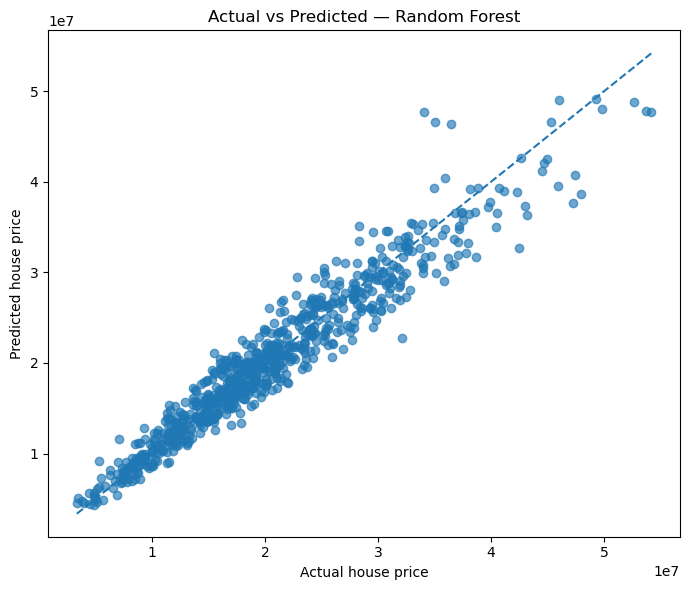

In [25]:
best_model_name = all_results.iloc[0]["model"]
best_estimator = dict(all_estimators)[best_model_name]
best_predictions = best_estimator.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.65)
lims = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual house price")
plt.ylabel("Predicted house price")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=160)
plt.show()


## Part H — Final analysis and business interpretation

1. **Best-performing model:** Select the model with the lowest test RMSE, while checking that the train-test gap is not excessively large.
2. **Impact of regularization:** Ridge and Lasso constrain coefficient size. This generally reduces variance and can make predictions more stable.
3. **Role of cross-validation:** Multiple folds expose performance variation across different samples and reduce dependence on one random split.
4. **Linear vs non-linear regressors:** Linear models are easier to interpret and work well when relationships are approximately additive. Trees and RBF-SVR can capture non-linear relationships but require complexity control and tuning.
5. **Business interpretation:** The model can support preliminary property pricing, portfolio screening, and valuation analysis. Predictions should be treated as estimates, not guaranteed market prices. Monitor drift, location changes, economic conditions, and data quality before production use.


In [26]:
best_row = all_results.iloc[0]
summary = pd.DataFrame([{
    "selected_model_by_test_rmse": best_row["model"],
    "test_rmse": best_row["test_rmse"],
    "test_mae": best_row["test_mae"],
    "test_r2": best_row["test_r2"],
    "note": "Selection is based on this synthetic dataset and should be revalidated with the official dataset."
}])
display(summary)
summary.to_csv(OUTPUT_DIR / "final_summary.csv", index=False)

,selected_model_by_test_rmse,test_rmse,test_mae,test_r2,note
0,Random Forest,2.420193e+06,1.773299e+06,0.92727,Selection is based on this synthetic dataset a...


In [27]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Select best model based on test RMSE
best_model_name = all_results.iloc[0]["model"]

best_estimator = dict(all_estimators)[best_model_name]

# Save trained pipeline
joblib.dump(
    best_estimator,
    MODEL_DIR / "best_model.joblib"
)

# Save model name
joblib.dump(
    best_model_name,
    MODEL_DIR / "model_name.joblib"
)

print("Best Model:", best_model_name)
print("Model exported successfully!")

Best Model: Random Forest
Model exported successfully!
